In [10]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import os

date_pull = '2024_09_07-Fall'
categ = 'commuter'
sql_file = 'parking_data_2024-09-07.sql'


os.makedirs(date_pull, exist_ok=True)
os.makedirs(f"{date_pull}/{categ}", exist_ok=True)
# Path to the SQL file


# Define an empty list to store extracted data
data = []

# Open the SQL dump file
with open(sql_file, 'r') as file:
    # Read the file line by line
    for line in file:
        # Check if the line starts with "INSERT INTO"
        if line.startswith("INSERT INTO"):
            # Extract the values from the line (assuming they are comma-separated)
            values = line.split("VALUES (")[1].rstrip(");\n").split("),(")
            # Parse each value and append it to the data list
            for value in values:
                data.append(tuple(value.strip("()").split(",")))

# Define column names
columns = ['ID', 'Zone_Id', 'Timestamp', 'Availability']
# Create DataFrame
df = pd.DataFrame(data, columns=columns)

# Convert 'Timestamp' column to DateTime format
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [11]:
# Get rid of Dates and only keep time of each entry for graphing
df['date'] = df['Timestamp'].dt.strftime('%Y-%m-%d')
df['time'] = df['Timestamp'].dt.strftime('%H:%M:%S')
df['hour'] = df['Timestamp'].dt.strftime('%H')
df['day_of_week'] = df['Timestamp'].dt.day_name()
df['Availability'] = df['Availability'].astype(float)
df['time'] = pd.to_datetime(df['time'])
df.fillna(0, inplace=True)
change = df

In [12]:
ids = ['13', '19', '4', '3']
df = df[df['Zone_Id'].isin(ids)]
df

,ID,Zone_Id,Timestamp,Availability,date,time,hour,day_of_week
1,2,13,2024-02-20 13:06:09,8.0,2024-02-20,2024-09-09 13:06:09,13,Tuesday
2,3,19,2024-02-20 13:06:09,59.0,2024-02-20,2024-09-09 13:06:09,13,Tuesday
3,4,4,2024-02-20 13:06:09,-7.0,2024-02-20,2024-09-09 13:06:09,13,Tuesday
4,5,3,2024-02-20 13:06:09,17.0,2024-02-20,2024-09-09 13:06:09,13,Tuesday
23,24,13,2024-02-20 13:07:10,10.0,2024-02-20,2024-09-09 13:07:10,13,Tuesday
...,...,...,...,...,...,...,...,...
8640646,8640647,19,2024-09-07 11:13:14,630.0,2024-09-07,2024-09-09 11:13:14,11,Saturday
8640647,8640648,4,2024-09-07 11:13:14,233.0,2024-09-07,2024-09-09 11:13:14,11,Saturday
8640665,8640666,13,2024-09-07 11:14:15,424.0,2024-09-07,2024-09-09 11:14:15,11,Saturday
8640666,8640667,19,2024-09-07 11:14:15,630.0,2024-09-07,2024-09-09 11:14:15,11,Saturday


In [13]:
# Narrow to only look at proper time
df = df[df['Timestamp'] > '2024-08-17']
df

,ID,Zone_Id,Timestamp,Availability,date,time,hour,day_of_week
8037725,8037726,13,2024-08-17 00:00:31,440.0,2024-08-17,2024-09-09 00:00:31,00,Saturday
8037726,8037727,19,2024-08-17 00:00:31,633.0,2024-08-17,2024-09-09 00:00:31,00,Saturday
8037727,8037728,4,2024-08-17 00:00:31,394.0,2024-08-17,2024-09-09 00:00:31,00,Saturday
8037745,8037746,13,2024-08-17 00:01:32,440.0,2024-08-17,2024-09-09 00:01:32,00,Saturday
8037746,8037747,19,2024-08-17 00:01:32,633.0,2024-08-17,2024-09-09 00:01:32,00,Saturday
...,...,...,...,...,...,...,...,...
8640646,8640647,19,2024-09-07 11:13:14,630.0,2024-09-07,2024-09-09 11:13:14,11,Saturday
8640647,8640648,4,2024-09-07 11:13:14,233.0,2024-09-07,2024-09-09 11:13:14,11,Saturday
8640665,8640666,13,2024-09-07 11:14:15,424.0,2024-09-07,2024-09-09 11:14:15,11,Saturday
8640666,8640667,19,2024-09-07 11:14:15,630.0,2024-09-07,2024-09-09 11:14:15,11,Saturday


In [14]:
df['Deck'] = ''
df.loc[(df['Zone_Id'] == '22'), 'Deck'] = 'Ballard'
df.loc[(df['Zone_Id'] == '13'), 'Deck'] = 'Champions'
df.loc[(df['Zone_Id'] == '19'), 'Deck'] = 'Chesapeake'
df.loc[(df['Zone_Id'] == '4'), 'Deck'] = 'Grace'
df.loc[(df['Zone_Id'] == '3'), 'Deck'] = 'Warsaw'

c:\Users\jacob\miniconda3\envs\myenv8\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
c:\Users\jacob\miniconda3\envs\myenv8\lib\site-packages\pandas\core\indexing.py:1817: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


In [15]:
df

,ID,Zone_Id,Timestamp,Availability,date,time,hour,day_of_week,Deck
8037725,8037726,13,2024-08-17 00:00:31,440.0,2024-08-17,2024-09-09 00:00:31,00,Saturday,Champions
8037726,8037727,19,2024-08-17 00:00:31,633.0,2024-08-17,2024-09-09 00:00:31,00,Saturday,Chesapeake
8037727,8037728,4,2024-08-17 00:00:31,394.0,2024-08-17,2024-09-09 00:00:31,00,Saturday,Grace
8037745,8037746,13,2024-08-17 00:01:32,440.0,2024-08-17,2024-09-09 00:01:32,00,Saturday,Champions
8037746,8037747,19,2024-08-17 00:01:32,633.0,2024-08-17,2024-09-09 00:01:32,00,Saturday,Chesapeake
...,...,...,...,...,...,...,...,...,...
8640646,8640647,19,2024-09-07 11:13:14,630.0,2024-09-07,2024-09-09 11:13:14,11,Saturday,Chesapeake
8640647,8640648,4,2024-09-07 11:13:14,233.0,2024-09-07,2024-09-09 11:13:14,11,Saturday,Grace
8640665,8640666,13,2024-09-07 11:14:15,424.0,2024-09-07,2024-09-09 11:14:15,11,Saturday,Champions
8640666,8640667,19,2024-09-07 11:14:15,630.0,2024-09-07,2024-09-09 11:14:15,11,Saturday,Chesapeake


In [21]:
df['Zone_Id'].unique()

array(['13', '19', '4'], dtype=object)

In [16]:
weekdays = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

In [17]:
# Need to drop
df['diff'] = df['Availability'].diff().abs()

threshold = 10
# Drop rows where the value is 0 and the difference with the previous or next value is greater than 10
df = df[~((df['Availability'] == 0) & (df['diff'] > 10) | (df['Availability'].shift(1).abs() < threshold))]

df = df[~((df['Availability'] == 0))]

# Drop the 'diff' column if it's no longer needed
df.drop(columns=['diff'], inplace=True)

c:\Users\jacob\miniconda3\envs\myenv8\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


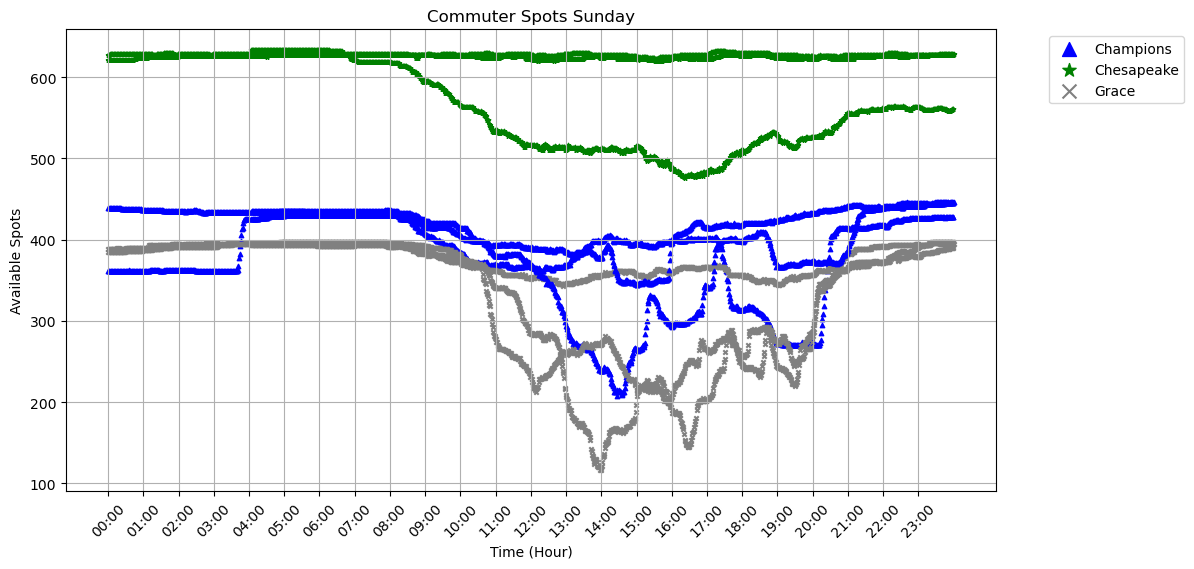

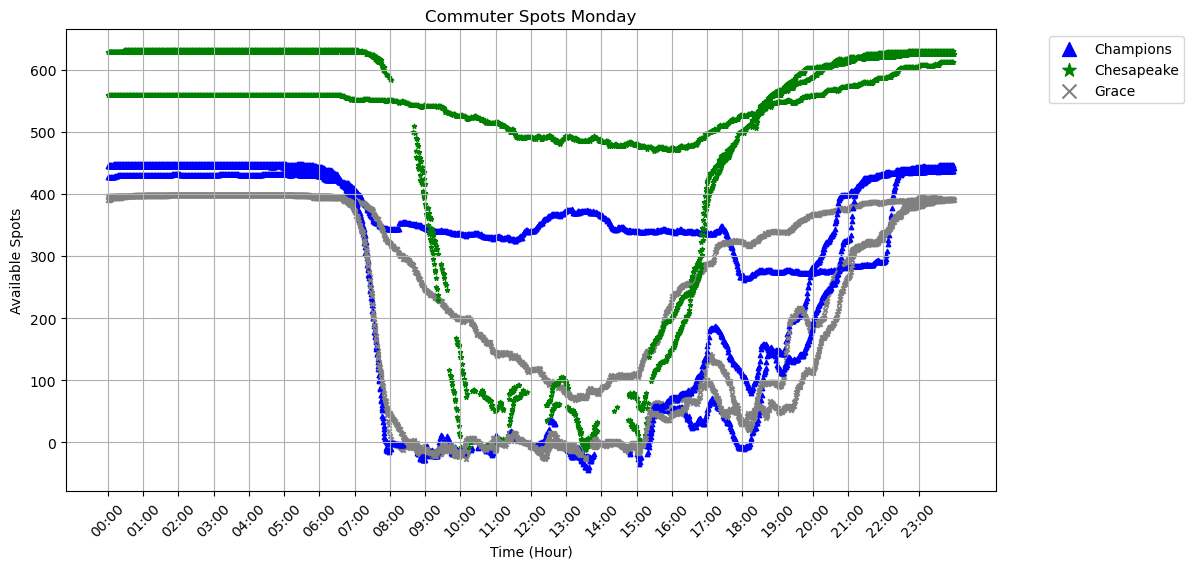

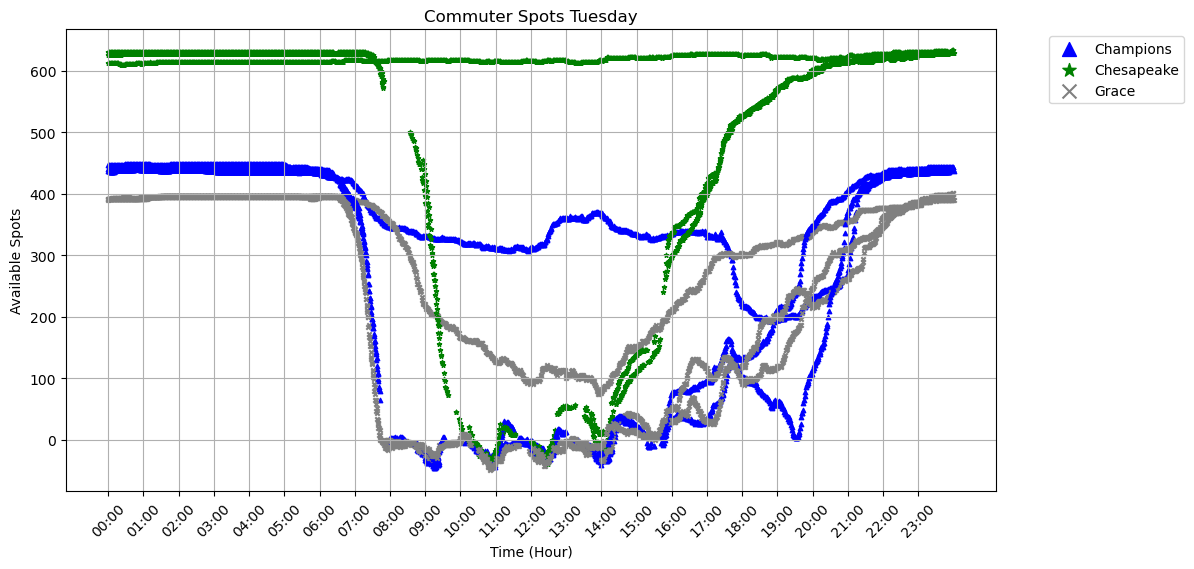

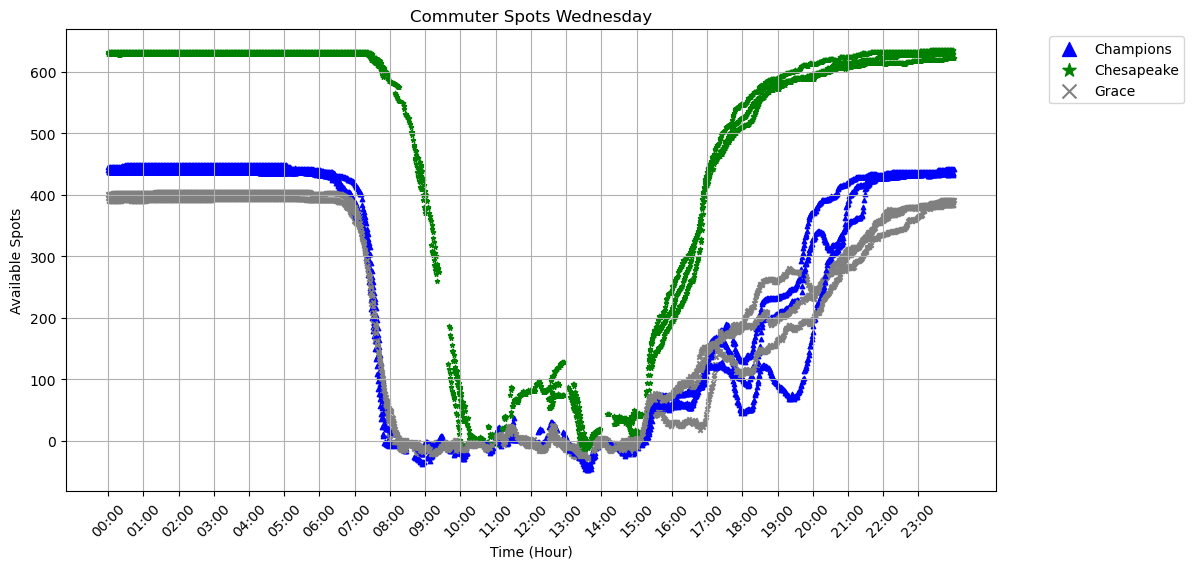

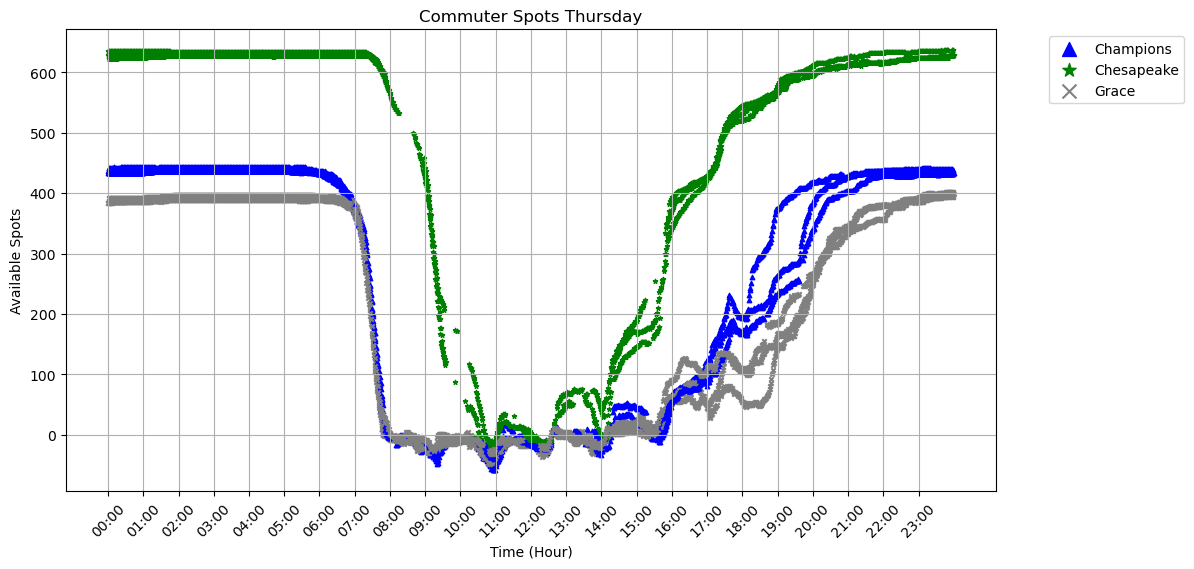

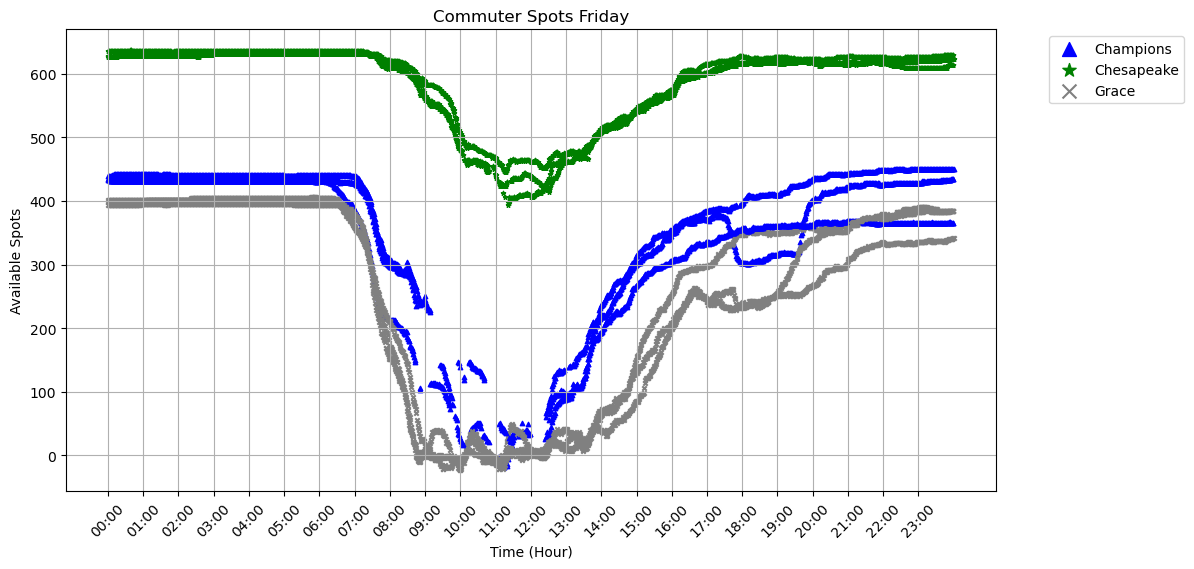

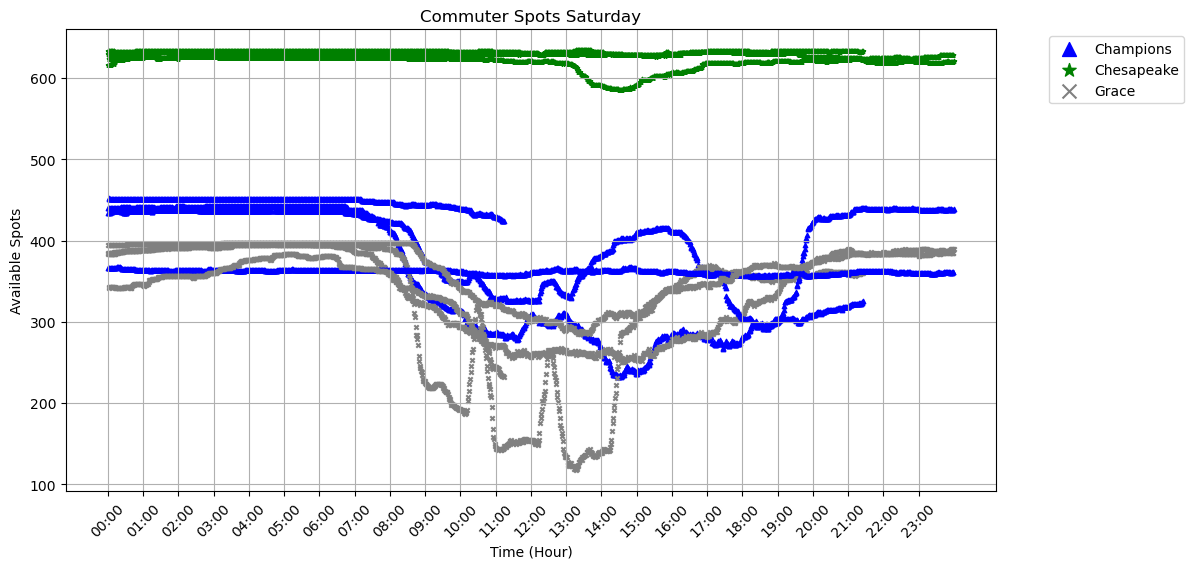

In [18]:
# Iterate through each deck

marker_types = {'Ballard': 's', 'Champions': '^', 'Chesapeake': '*', 'Grace': 'x', 'Warsaw': '+'}
color_types = {'Ballard': 'red', 'Champions': 'blue', 'Chesapeake': 'green', 'Grace': 'gray', 'Warsaw': 'orange'}


for day in weekdays:
    os.makedirs(f"{date_pull}/{categ}/{day}", exist_ok=True)
    df_com = df.loc[df['day_of_week'] == day]

    df_com = df_com.sort_values(by='time')

    # plot and save
    plt.figure(figsize=(12, 6))

    legend_labels_set = set()
    legend_handles_set = set()

    for date, group in df_com.groupby('date'):
        for deck, deck_group in group.groupby('Deck'):
            marker = marker_types.get(deck, 'o')
            color = color_types.get(deck, 'black')
            plt.scatter(deck_group['time'], deck_group['Availability'], s=10, marker=marker, color=color)
            if deck not in legend_labels_set:
                legend_labels_set.add(deck)
                legend_handles_set.add((plt.scatter([], [], label=deck, s=20, marker=marker, color=color), deck))
        

    plt.xticks(pd.date_range('00:00', '23:00', freq='H'), [f'{hour:02d}:00' for hour in range(24)])
    plt.grid()
    plt.xlabel('Time (Hour)')
    plt.ylabel('Available Spots')
    plt.title(f'Commuter Spots {day}')
    
    # Sort legend handles by deck name
    legend_handles_sorted = sorted(legend_handles_set, key=lambda x: x[1])
    
    # Extract handles from sorted legend handles
    legend_handles = [handle[0] for handle in legend_handles_sorted]
    
    # Extract labels from sorted legend handles
    legend_labels = [handle[1] for handle in legend_handles_sorted]

    legend = plt.legend(handles=legend_handles, labels=legend_labels, bbox_to_anchor=(1.05, 1), loc='upper left', scatterpoints=1)
    plt.xticks(rotation=45)

    for handle in legend.legendHandles:
        handle.set_sizes([100]) 

    plt.savefig(f'{date_pull}/{categ}/{day}.png', bbox_inches='tight')